## IMPORTING LIBRARIES


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("7_real_estate_prices.csv")

In [4]:
df.head()

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,days_on_market,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property
0,PROP_00000001,17-09-2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,37,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes
1,PROP_00000002,27-04-2023,Single Family,Seattle,Premium,1.67,6,9.2,85,2,...,5,Fall,Stable,7.15,Yes,Yes,No,307.0,687536,No
2,PROP_00000003,28-11-2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,7,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes
3,PROP_00000004,15-02-2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,86,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes
4,PROP_00000005,07-11-2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,88,Spring,Rising,5.90,Yes,No,No,160.0,691008,No


In [5]:
df.isnull().sum()

property_id                      0
listing_date                     0
property_type                    0
city                             0
neighborhood_tier                0
zipcode_crime_rate               0
school_rating                    0
distance_to_downtown_miles       0
walk_score                       0
bedrooms                         0
bathrooms                        0
square_feet                    750
lot_size_sqft                    0
stories                          0
garage_spaces                    0
year_built                       0
house_age                        0
has_basement                     0
has_pool                         0
overall_condition                0
kitchen_quality                  0
hvac_condition                   0
roof_condition                   0
renovation_year               8505
years_since_renovation           0
days_on_market                   0
listing_season                   0
market_trend                     0
interest_rate       

In [6]:
df["square_feet"] = df["square_feet"].fillna(df["square_feet"].median())
df["hoa_fees"] = df["hoa_fees"].fillna(0)
df["was_renovated"] = df["renovation_year"].notnull().astype(int)

In [7]:
df.drop("renovation_year",axis = 1,inplace = True)
df.drop("property_id",axis = 1,inplace = True)

In [8]:
df.isnull().sum()

listing_date                  0
property_type                 0
city                          0
neighborhood_tier             0
zipcode_crime_rate            0
school_rating                 0
distance_to_downtown_miles    0
walk_score                    0
bedrooms                      0
bathrooms                     0
square_feet                   0
lot_size_sqft                 0
stories                       0
garage_spaces                 0
year_built                    0
house_age                     0
has_basement                  0
has_pool                      0
overall_condition             0
kitchen_quality               0
hvac_condition                0
roof_condition                0
years_since_renovation        0
days_on_market                0
listing_season                0
market_trend                  0
interest_rate                 0
has_fireplace                 0
has_patio_deck                0
has_security_system           0
hoa_fees                      0
sale_pri

In [9]:
# df = pd.get_dummies(df, drop_first=True)
df.select_dtypes(include="object").columns

C:\Users\SafirudinKM\AppData\Local\Temp\ipykernel_8636\468500996.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['listing_date', 'property_type', 'city', 'neighborhood_tier',
       'has_basement', 'has_pool', 'overall_condition', 'kitchen_quality',
       'hvac_condition', 'roof_condition', 'listing_season', 'market_trend',
       'has_fireplace', 'has_patio_deck', 'has_security_system',
       'high_value_property'],
      dtype='str')

In [10]:
df.head()

,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,bathrooms,...,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property,was_renovated
0,17-09-2023,Condo,Denver,Premium,1.33,6,33.5,38,4,3.0,...,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes,1
1,27-04-2023,Single Family,Seattle,Premium,1.67,6,9.2,85,2,2.5,...,Fall,Stable,7.15,Yes,Yes,No,307.0,687536,No,1
2,28-11-2023,Single Family,Austin,Average,1.16,6,2.1,98,6,3.0,...,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes,1
3,15-02-2023,Single Family,Austin,Good,0.97,8,2.8,46,4,4.0,...,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes,1
4,07-11-2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,1.0,...,Spring,Rising,5.90,Yes,No,No,160.0,691008,No,0


In [11]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].nunique())

listing_date 365
property_type 4
city 5
neighborhood_tier 4
has_basement 2
has_pool 2
overall_condition 4
kitchen_quality 4
hvac_condition 4
roof_condition 4
listing_season 4
market_trend 3
has_fireplace 2
has_patio_deck 2
has_security_system 2
high_value_property 2


C:\Users\SafirudinKM\AppData\Local\Temp\ipykernel_8636\1826314449.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [12]:
print(list(df.columns))

['listing_date', 'property_type', 'city', 'neighborhood_tier', 'zipcode_crime_rate', 'school_rating', 'distance_to_downtown_miles', 'walk_score', 'bedrooms', 'bathrooms', 'square_feet', 'lot_size_sqft', 'stories', 'garage_spaces', 'year_built', 'house_age', 'has_basement', 'has_pool', 'overall_condition', 'kitchen_quality', 'hvac_condition', 'roof_condition', 'years_since_renovation', 'days_on_market', 'listing_season', 'market_trend', 'interest_rate', 'has_fireplace', 'has_patio_deck', 'has_security_system', 'hoa_fees', 'sale_price', 'high_value_property', 'was_renovated']


In [13]:
df["listing_date"] = pd.to_datetime(df["listing_date"])

C:\Users\SafirudinKM\AppData\Local\Temp\ipykernel_8636\1439737229.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["listing_date"] = pd.to_datetime(df["listing_date"])


In [14]:
df["listing_year"] = df["listing_date"].dt.year
df["listing_month"] = df["listing_date"].dt.month
df["listing_day"] = df["listing_date"].dt.day

In [15]:
df.columns

Index(['listing_date', 'property_type', 'city', 'neighborhood_tier',
       'zipcode_crime_rate', 'school_rating', 'distance_to_downtown_miles',
       'walk_score', 'bedrooms', 'bathrooms', 'square_feet', 'lot_size_sqft',
       'stories', 'garage_spaces', 'year_built', 'house_age', 'has_basement',
       'has_pool', 'overall_condition', 'kitchen_quality', 'hvac_condition',
       'roof_condition', 'years_since_renovation', 'days_on_market',
       'listing_season', 'market_trend', 'interest_rate', 'has_fireplace',
       'has_patio_deck', 'has_security_system', 'hoa_fees', 'sale_price',
       'high_value_property', 'was_renovated', 'listing_year', 'listing_month',
       'listing_day'],
      dtype='str')

In [16]:
df = df.drop("listing_year", axis=1)

In [83]:
df = pd.get_dummies(df,drop_first=True)

In [84]:
df['age_category'] = pd.cut(
    df['house_age'],
    bins=[0,10,30,60,100],
    labels=['New','Moderate','Old','Very Old']
)

In [92]:
df["Total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [86]:
print(df["age_category"])


0        Very Old
1        Very Old
2             Old
3             Old
4        Very Old
           ...   
14995         Old
14996    Very Old
14997         Old
14998         New
14999    Moderate
Name: age_category, Length: 15000, dtype: category
Categories (4, str): ['New' < 'Moderate' < 'Old' < 'Very Old']


In [19]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [93]:
print(df.columns)

Index(['listing_date', 'zipcode_crime_rate', 'school_rating',
       'distance_to_downtown_miles', 'walk_score', 'bedrooms', 'bathrooms',
       'square_feet', 'lot_size_sqft', 'stories', 'garage_spaces',
       'year_built', 'house_age', 'years_since_renovation', 'days_on_market',
       'interest_rate', 'hoa_fees', 'sale_price', 'was_renovated',
       'listing_month', 'listing_day', 'property_type_multi-family',
       'property_type_single_family', 'property_type_townhouse', 'city_austin',
       'city_denver', 'city_phoenix', 'city_seattle',
       'neighborhood_tier_developing', 'neighborhood_tier_good',
       'neighborhood_tier_premium', 'has_basement_yes', 'has_pool_yes',
       'overall_condition_fair', 'overall_condition_good',
       'overall_condition_poor', 'kitchen_quality_basic',
       'kitchen_quality_good', 'kitchen_quality_premium',
       'hvac_condition_good', 'hvac_condition_new', 'hvac_condition_old',
       'roof_condition_good', 'roof_condition_needs_replaceme

In [21]:
df.head()

,listing_date,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,bathrooms,square_feet,lot_size_sqft,stories,...,roof_condition_new,listing_season_spring,listing_season_summer,listing_season_winter,market_trend_rising,market_trend_stable,has_fireplace_yes,has_patio_deck_yes,has_security_system_yes,high_value_property_yes
0,2023-09-17,1.33,6,33.5,38,4,3.0,2205.0,10019,2,...,False,False,True,False,False,True,False,True,True,True
1,2023-04-27,1.67,6,9.2,85,2,2.5,1736.0,1000,1,...,True,False,False,False,False,True,True,True,False,False
2,2023-11-28,1.16,6,2.1,98,6,3.0,3093.0,30134,2,...,False,False,False,False,True,False,False,True,False,True
3,2023-02-15,0.97,8,2.8,46,4,4.0,2181.0,11487,2,...,False,False,True,False,False,True,True,False,False,True
4,2023-11-07,2.64,7,10.2,54,3,1.0,2303.0,3577,2,...,False,True,False,False,True,False,True,False,False,False


In [23]:
df[["distance_to_downtown_miles","sale_price"]].corr()

,distance_to_downtown_miles,sale_price
distance_to_downtown_miles,1.000000,-0.013632
sale_price,-0.013632,1.000000


In [76]:
from scipy.stats import pearsonr
import numpy as np

r, p = pearsonr(df["distance_to_downtown_miles"], df["sale_price"])

n = len(df)
t_stat = r * np.sqrt((n-2)/(1-r**2))

print("Correlation:", r)
print("t-statistic:", t_stat)
print("p-value:", p)

Correlation: -0.013632493398456272
t-statistic: -1.6696764824696513
p-value: 0.09500425801941997


In [78]:
from scipy.stats import ttest_ind

rising = df[df["market_trend_rising"] == 1]["sale_price"]
not_rising = df[df["market_trend_rising"] == 0]["sale_price"]

t_stat, p = ttest_ind(rising, not_rising)

print("T-statistic:", t_stat)
print("P-value:", p)

T-statistic: 0.6713778052723899
P-value: 0.5019902203505708


In [25]:
# df["school_rating"].corr(df["sale_price"])
df[["school_rating", "sale_price"]].corr()

,school_rating,sale_price
school_rating,1.000000,0.122919
sale_price,0.122919,1.000000


In [26]:
from scipy.stats import ttest_ind

ren = df[df["was_renovated"] == 1]["sale_price"]
no_ren = df[df["was_renovated"] == 0]["sale_price"]

ttest_ind(ren, no_ren)

TtestResult(statistic=np.float64(-0.8792155455653475), pvalue=np.float64(0.37929850318517244), df=np.float64(14998.0))

In [27]:
df["bedrooms"].corr(df["sale_price"])
df[["bedrooms", "sale_price"]].corr()

,bedrooms,sale_price
bedrooms,1.000000,0.583443
sale_price,0.583443,1.000000


In [28]:
df["bedrooms"].corr(df["sale_price"])

np.float64(0.5834428709110931)

In [29]:
df[[
    "overall_condition_good",
    "overall_condition_poor",
    "sale_price"
]].corr()

,overall_condition_good,overall_condition_poor,sale_price
overall_condition_good,1.000000,-0.266619,0.017366
overall_condition_poor,-0.266619,1.000000,-0.048224
sale_price,0.017366,-0.048224,1.000000


In [30]:
df["garage_spaces"].corr(df["sale_price"])

np.float64(0.014733227448731843)

In [31]:
df["walk_score"].corr(df["sale_price"])

np.float64(0.0021180898015305603)

In [32]:
df["house_age"].corr(df["sale_price"])

np.float64(-0.4509070740006846)

Text(0.5, 1.0, 'Square Feet vs Sale Price')

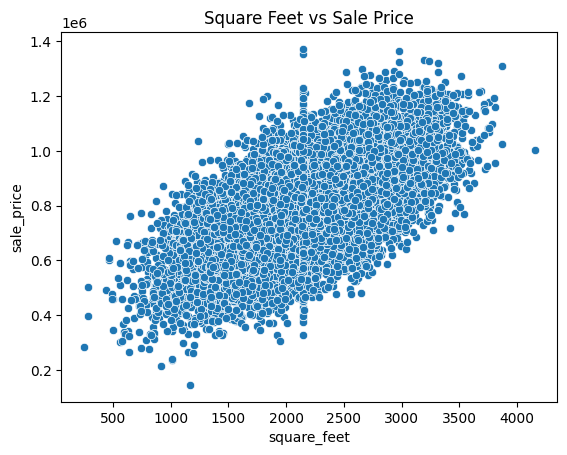

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="square_feet", y="sale_price", data=df)
plt.title("Square Feet vs Sale Price")

Text(0.5, 1.0, 'Bedrooms vs Sale Price')

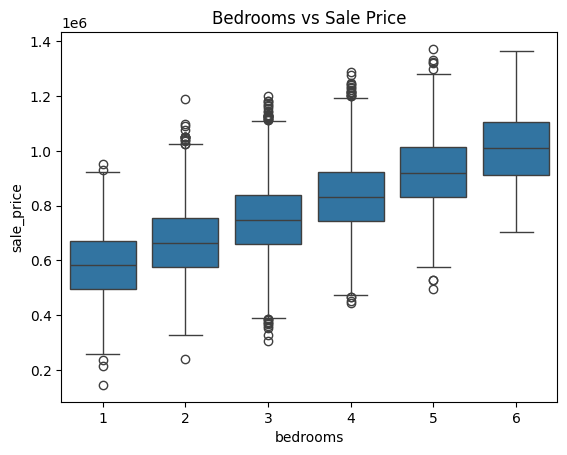

In [34]:
sns.boxplot(x="bedrooms", y="sale_price", data=df)
plt.title("Bedrooms vs Sale Price")


Text(0.5, 1.0, 'Year Built vs Sale Price')

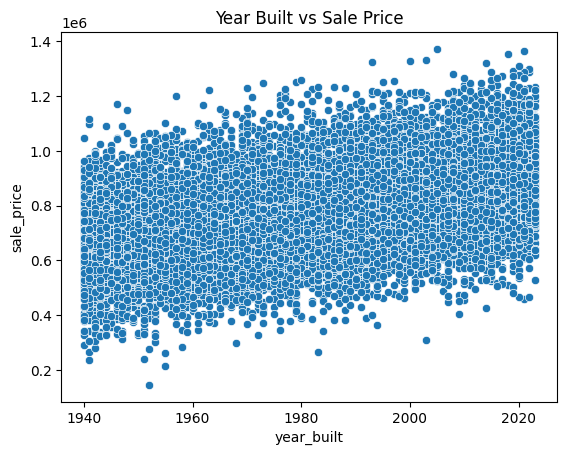

In [35]:
sns.scatterplot(x="year_built", y="sale_price", data=df)
plt.title("Year Built vs Sale Price")

Text(0.5, 1.0, 'House Age vs Sale Price')

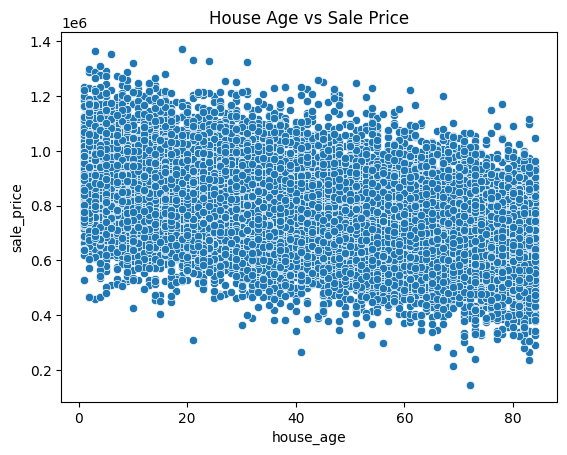

In [36]:
sns.scatterplot(x="house_age", y="sale_price", data=df)
plt.title("House Age vs Sale Price")

Text(0.5, 1.0, 'Lot Size vs Sale Price')

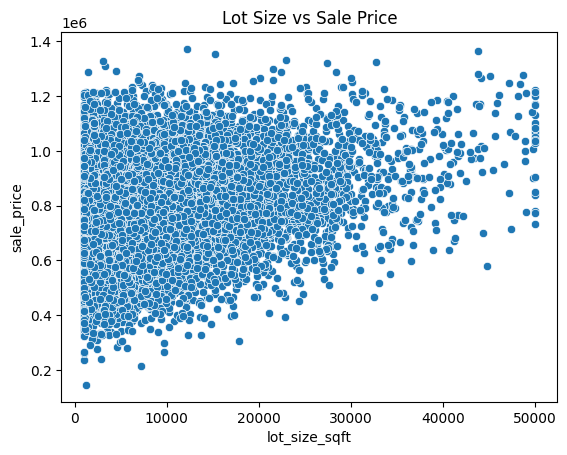

In [37]:
sns.scatterplot(x="lot_size_sqft", y="sale_price", data=df)
plt.title("Lot Size vs Sale Price")

Text(0.5, 1.0, 'Premium Neighborhood vs Price')

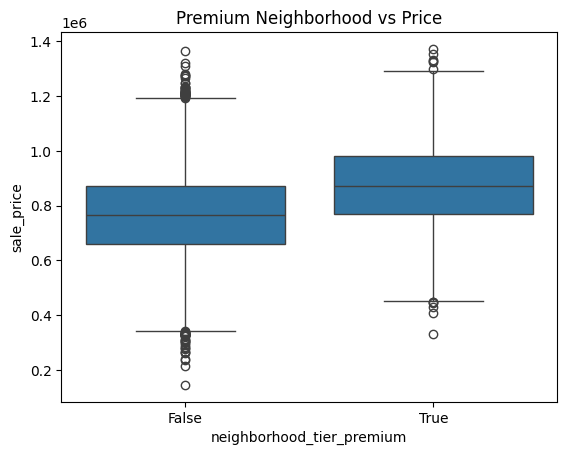

In [38]:
sns.boxplot(x="neighborhood_tier_premium", y="sale_price", data=df)
plt.title("Premium Neighborhood vs Price")

Text(0.5, 1.0, 'Bathrooms vs Sale Price')

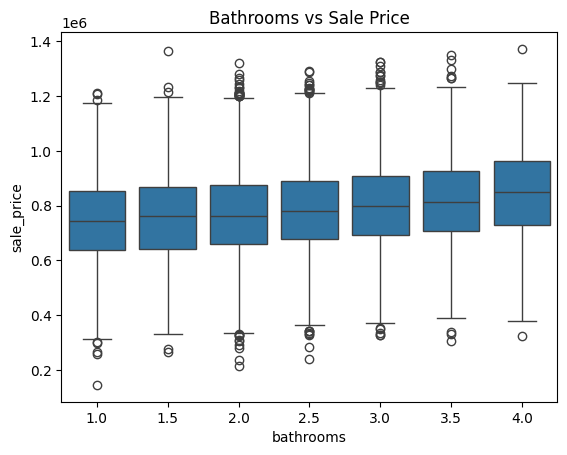

In [39]:
sns.boxplot(x="bathrooms", y="sale_price", data=df)
plt.title("Bathrooms vs Sale Price")

Text(0.5, 1.0, 'School Rating vs Price')

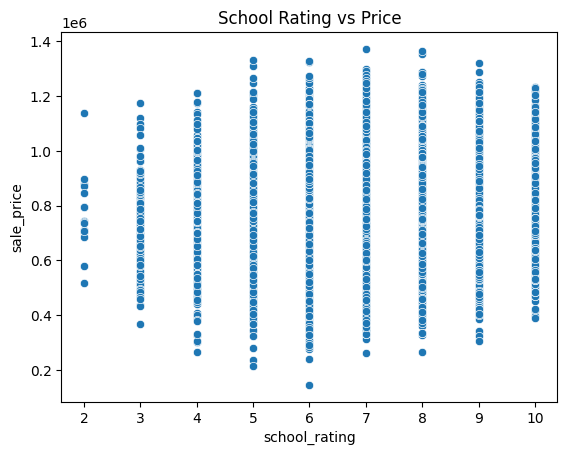

In [40]:
sns.scatterplot(x="school_rating", y="sale_price", data=df)
plt.title("School Rating vs Price")

Text(0.5, 1.0, 'Kitchen Quality Premium vs Price')

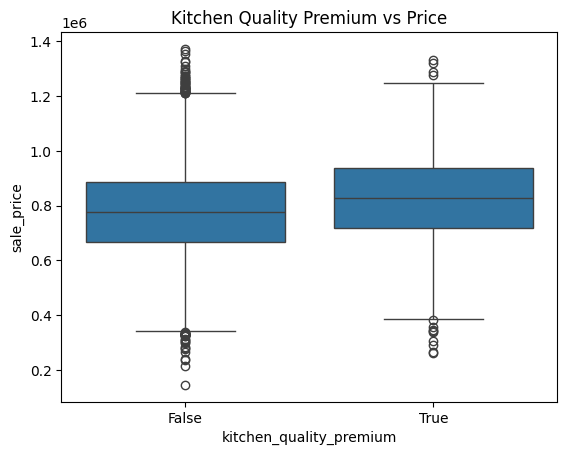

In [41]:
sns.boxplot(x="kitchen_quality_premium", y="sale_price", data=df)
plt.title("Kitchen Quality Premium vs Price")

Text(0.5, 1.0, 'Years Since Renovation vs Price')

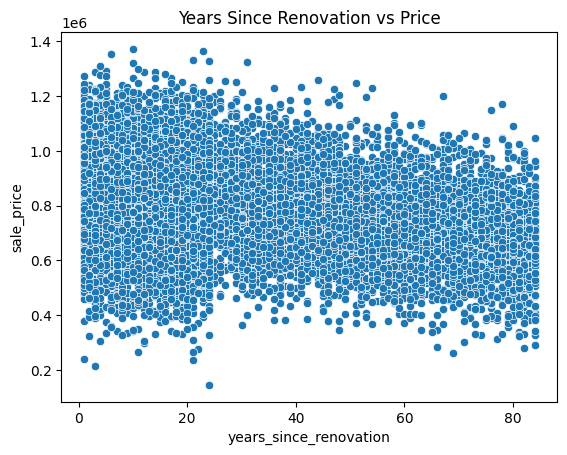

In [42]:
sns.scatterplot(x="years_since_renovation", y="sale_price", data=df)
plt.title("Years Since Renovation vs Price")

<Axes: >

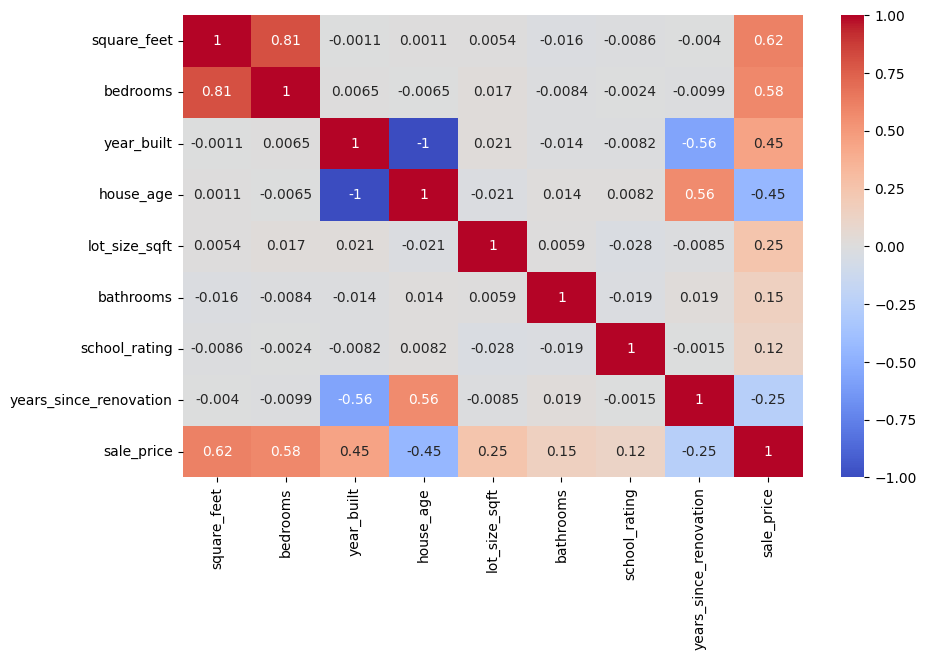

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[
        [
            "square_feet",
            "bedrooms",
            "year_built",
            "house_age",
            "lot_size_sqft",
            "bathrooms",
            "school_rating",
            "years_since_renovation",
            "sale_price"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

In [80]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df.columns

Index(['listing_date', 'zipcode_crime_rate', 'school_rating',
       'distance_to_downtown_miles', 'walk_score', 'bedrooms', 'bathrooms',
       'square_feet', 'lot_size_sqft', 'stories', 'garage_spaces',
       'year_built', 'house_age', 'years_since_renovation', 'days_on_market',
       'interest_rate', 'hoa_fees', 'sale_price', 'was_renovated',
       'listing_month', 'listing_day', 'property_type_multi-family',
       'property_type_single_family', 'property_type_townhouse', 'city_austin',
       'city_denver', 'city_phoenix', 'city_seattle',
       'neighborhood_tier_developing', 'neighborhood_tier_good',
       'neighborhood_tier_premium', 'has_basement_yes', 'has_pool_yes',
       'overall_condition_fair', 'overall_condition_good',
       'overall_condition_poor', 'kitchen_quality_basic',
       'kitchen_quality_good', 'kitchen_quality_premium',
       'hvac_condition_good', 'hvac_condition_new', 'hvac_condition_old',
       'roof_condition_good', 'roof_condition_needs_replaceme

SQUARE FEET INCREASE SALES PRICE


In [89]:
from scipy import stats
 
r, p = stats.pearsonr(df["square_feet"], df["sale_price"])

print("Correlation:", r)
print("p-value:", p)
 
if p < 0.05:
    print("Reject H0 - square_feet is significant")
else:
    print("Fail to reject H0")

Correlation: 0.6150009379111868
p-value: 0.0
Reject H0 - square_feet is significant


SCHOOL RATING INCREASES SCHOOL PRICE

In [90]:
print(df[['sale_price','school_rating']].corr())

               sale_price  school_rating
sale_price       1.000000       0.122919
school_rating    0.122919       1.000000


RISING TREND INCREASES THE PRICE

In [81]:
from scipy.stats import ttest_ind

rising = df[df["market_trend_rising"] == 1]["sale_price"]
not_rising = df[df["market_trend_rising"] == 0]["sale_price"]

t_stat, p = ttest_ind(rising, not_rising)

print("T-statistic:", t_stat)
print("P-value:", p)

T-statistic: 0.6713778052723899
P-value: 0.5019902203505708


AGE OF HOUSE AFFECTS PRICE

In [91]:
from scipy import stats

new = df[df['age_category'] == 'New']['sale_price']
moderate = df[df['age_category'] == 'Moderate']['sale_price']
old = df[df['age_category'] == 'Old']['sale_price']
very_old = df[df['age_category'] == 'Very Old']['sale_price']

f_stat, p_value = stats.f_oneway(new, moderate, old, very_old)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 — house age category affects price")
else:
    print("Fail to reject H0")

F-statistic: 1147.3826259510333
p-value: 0.0
Reject H0 — house age category affects price


Total Rooms increases the sales price

In [95]:
from scipy import stats

r, p = stats.pearsonr(df["Total_rooms"], df["sale_price"])

print("Correlation:", r)
print("p-value:", p)

if p < 0.05:
    print("Reject H0 — Total_rooms increases price")
else:
    print("Fail to reject H0")

Correlation: 0.5691111253006714
p-value: 0.0
Reject H0 — Total_rooms increases price


RENOVATION INCREASES THE PRICES

In [99]:
renovated = df[df['was_renovated']==1]['sale_price']
not_renovated = df[df['was_renovated']==0]['sale_price']
t_stat, p_val = stats.ttest_ind(renovated, not_renovated)
print("T-test:", t_stat, "p-value:", p_val)

print("Renovated mean:", renovated.mean())
print("Not renovated mean:", not_renovated.mean())

T-test: -0.8792155455653475 p-value: 0.37929850318517244
Renovated mean: 781392.5655119322
Not renovated mean: 783743.1131099353


In [98]:
features = [
    "high_value_property_yes",
    "city_seattle",
    "city_phoenix",
    "square_feet",
    "bedrooms",
    "year_built",
    "house_age",
    "lot_size_sqft",
    "neighborhood_tier_premium",
    "bathrooms",
    "school_rating",
    "kitchen_quality_premium",
    "years_since_renovation"
]

X = df[features]
y = df["sale_price"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(random_state=42)
# model.fit(X_train, y_train)

In [48]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.8350985336966387
MAE: 52643.08568907776
